## Background

Author: Diane Menuz  
Date: 7/23/2026  
Goal: Download [forcing variables](https://ldas.gsfc.nasa.gov/nldas/v2/forcing) from NLDAS and use to calculate hourly ETo with refet package  
  
Downloads are based on this nasa [tutorial](https://github.com/nasa/gesdisc-tutorials/blob/main/notebooks/How_to_Access_GiC_Time_Series_Service.ipynb)  
 
NLDAS data are returned as UTC and refet uses UTC for calculations.

Initial Set Up
- Register for an [Earthdata](https://urs.earthdata.nasa.gov/) account
- Log in to account and generate a token
- Copy token as parameter into script below; note that tokens are good for a limited   
period of time
- If call_nldas_time_series throws an error, you may need to turn on some apps under the  
Authorized Apps in your Earthdata account. I experimented with turning on the following  
but in the end did not need any of them:
  - Giovanni
  - NASA GESDISC DATA ARCHIVE	 
  - Hyrax in the cloud	 
  - New Harmony Giovanni Adapter

## Import Libraries

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import refet

sys.path.insert(0, os.path.abspath("../../src"))  # adjust path as needed
from fluxfootprints import fetch_nldas_forcing_dataset

## Parameters

Copy your token from Earthdata into the parameters below

In [3]:
# token from EArthdata
token = "PASTE YOUR TOKEN HERE"
token = os.environ['EARTHDATA_TOKEN']  # or set an environment variable EARTHDATA_TOKEN with your token

In [4]:
# station parameters
# note that the time start and end should be in UTC
lat = 37.7359692085905
lon = -111.55517578125
elevation_m = 1729.3
time_start =  '2025-06-01'
time_end = '2025-06-30'
utc_offset = -7

## Download NLDAS Data and Format

In [5]:
# format datetime and d
time_start = pd.to_datetime(time_start)
time_start = time_start.strftime("%Y-%m-%dT%H:%M:%S")
time_end = pd.to_datetime(time_end)
time_end = time_end.strftime("%Y-%m-%dT%H:%M:%S")

In [6]:
# obtain nldas data for site and date range
nldas_raw = fetch_nldas_forcing_dataset(lat, lon, time_start, time_end, token)
nldas_raw['timestamp_local'] = nldas_raw.index + pd.Timedelta(hours=utc_offset)

Fetching temp_K...
Status Code: 200
Fetching spec_hum...
Status Code: 200
Fetching pressure_pa...
Status Code: 200
Fetching wind_u10...
Status Code: 200
Fetching wind_v10...
Status Code: 200
Fetching solar_rad...
Status Code: 200


In [12]:
# convert variables as needed and calculate hourly ref et
df = nldas_raw.copy()

# Compute 10m wind speed magnitude from NLDAS zonal/meridional vectors
df["wind_10m"] = np.sqrt(df["wind_u10"] ** 2 + df["wind_v10"] ** 2)

# Compute actual vapor pressure (ea) in kPa from specific humidity (q) & surface pressure (P)
p_kpa = df["pressure_pa"] / 1000.0
df["ea_kpa"] = (df["spec_hum"] * p_kpa) / (
    0.622 + (1.0 - 0.622) * df["spec_hum"]
)

# run hourly model
refet_model = refet.Hourly(
    tmean=df["temp_K"],  # Temperature in Kelvin
    ea=df["ea_kpa"],  # Actual vapor pressure in kPa
    rs=df["solar_rad"],  # Solar radiation in W/m^2
    uz=df["wind_10m"],  # Wind speed in m/s at 10m
    zw=10,  # Tell refet wind is measured at 10m
    elev=elevation_m,  # Elevation in meters
    lat=lat,  # Latitude in degrees
    lon=lon,  # Longitude in degrees
    doy=df.index.dayofyear,  # Day of year (1-366)
    time=df.index.hour,  # UTC hour (0-23)
    method="asce",
    input_units={
        "tmean": "K",  # Kelvin -> refet converts to C internally
        "rs": "w/m2",  # W/m2 -> refet converts to MJ/m2/hr internally
        "lat": "deg",  # Degrees -> refet converts to rad internally
        "uz": "m/s",
    },
)

# xtract short grass (ETo) in mm/hr
df["eto_grass"] = refet_model.eto()

# Compute each hour's fraction relative to the daily total
daily_total_eto = df.groupby(df.timestamp_local.dt.date)["eto_grass"].transform("sum")
df["eto_hourly_fraction"] = df["eto_grass"] / daily_total_eto

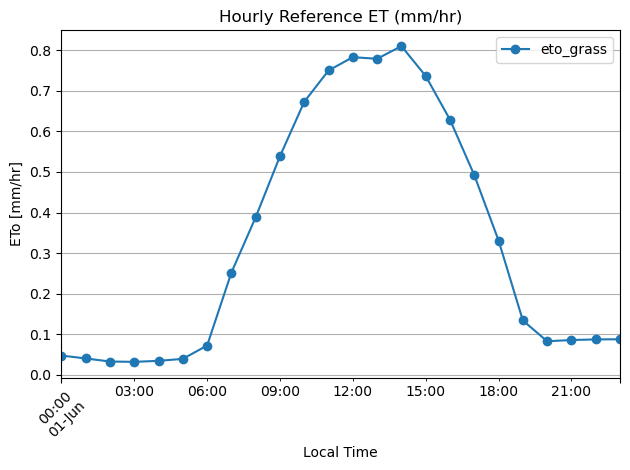

In [13]:
 # plot a single day- make sure time alignment is correct
second_date = df["timestamp_local"].dt.date.unique()[1]
one_day = df[df["timestamp_local"].dt.date == second_date]
one_day.plot(x="timestamp_local", y="eto_grass", grid=True, marker="o")
plt.title("Hourly Reference ET (mm/hr)")
plt.ylabel("ETo [mm/hr]")
plt.xlabel("Local Time")
plt.xticks(rotation=45)  # Rotates timestamps so they don't overlap
plt.tight_layout()
plt.show()